## Training Model MobileNetV2 dengan Hyperparameter Tuning Terbaik

In [1]:
# Import library
import numpy as numpy
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

In [2]:
# Konfigurasi
DATASET_PATH = r'C:\Users\ACER\Downloads\dump\task\data'
train_dir = os.path.join(DATASET_PATH, 'Train')
val_dir = os.path.join(DATASET_PATH, 'Val')
test_dir = os.path.join(DATASET_PATH, 'Test')

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 100

### Distribusi Pembagian Dataset

Total gambar di Train: 9169
Total gambar di Validation: 1924
Total gambar di Test: 1924


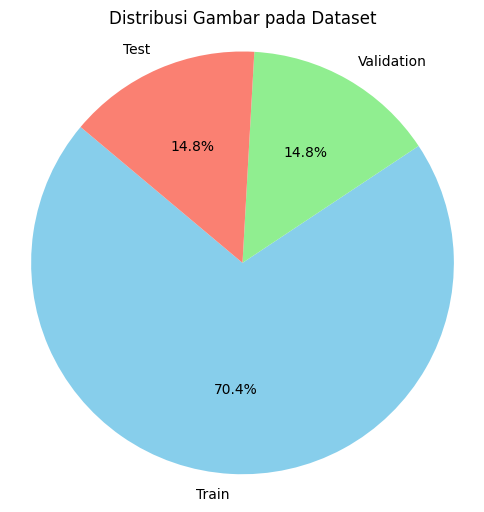

In [3]:
# Fungsi menghitung jumlah gambar di folder (semua subfolder dihitung)
def count_images(directory):
    total = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                total += 1
    return total

# Hitung total gambar otomatis
train_total = count_images(train_dir)
val_total = count_images(val_dir)
test_total = count_images(test_dir)

# Tampilkan jumlah
print(f"Total gambar di Train: {train_total}")
print(f"Total gambar di Validation: {val_total}")
print(f"Total gambar di Test: {test_total}")

# Pie Chart
labels = ['Train', 'Validation', 'Test']
sizes = [train_total, val_total, test_total]
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Gambar pada Dataset')
plt.axis('equal')  # Biar bulat
plt.show()


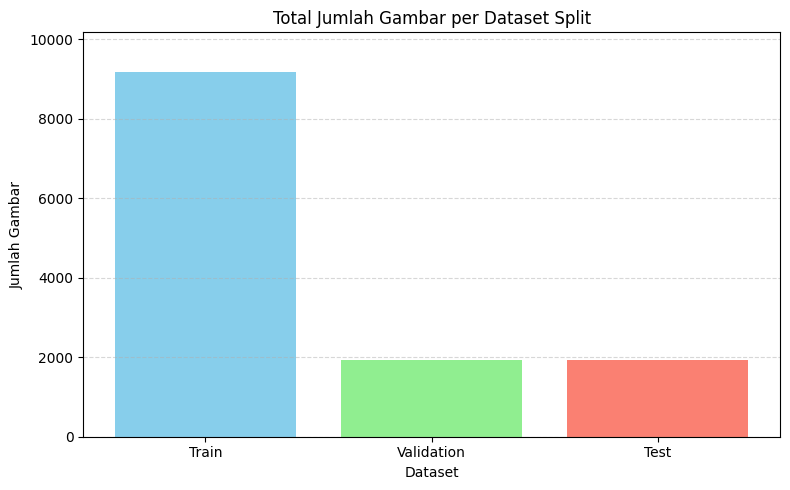

In [5]:
dataset_splits = ['Train', 'Validation', 'Test']
total_counts = [train_total, val_total, test_total]
colors = ['skyblue', 'lightgreen', 'salmon']

# Plot histogram
plt.figure(figsize=(8, 5))
plt.bar(dataset_splits, total_counts, color=colors)
plt.title('Total Jumlah Gambar per Dataset Split')
plt.xlabel('Dataset')
plt.ylabel('Jumlah Gambar')
plt.ylim(0, max(total_counts) + 1000)  # beri ruang di atas
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

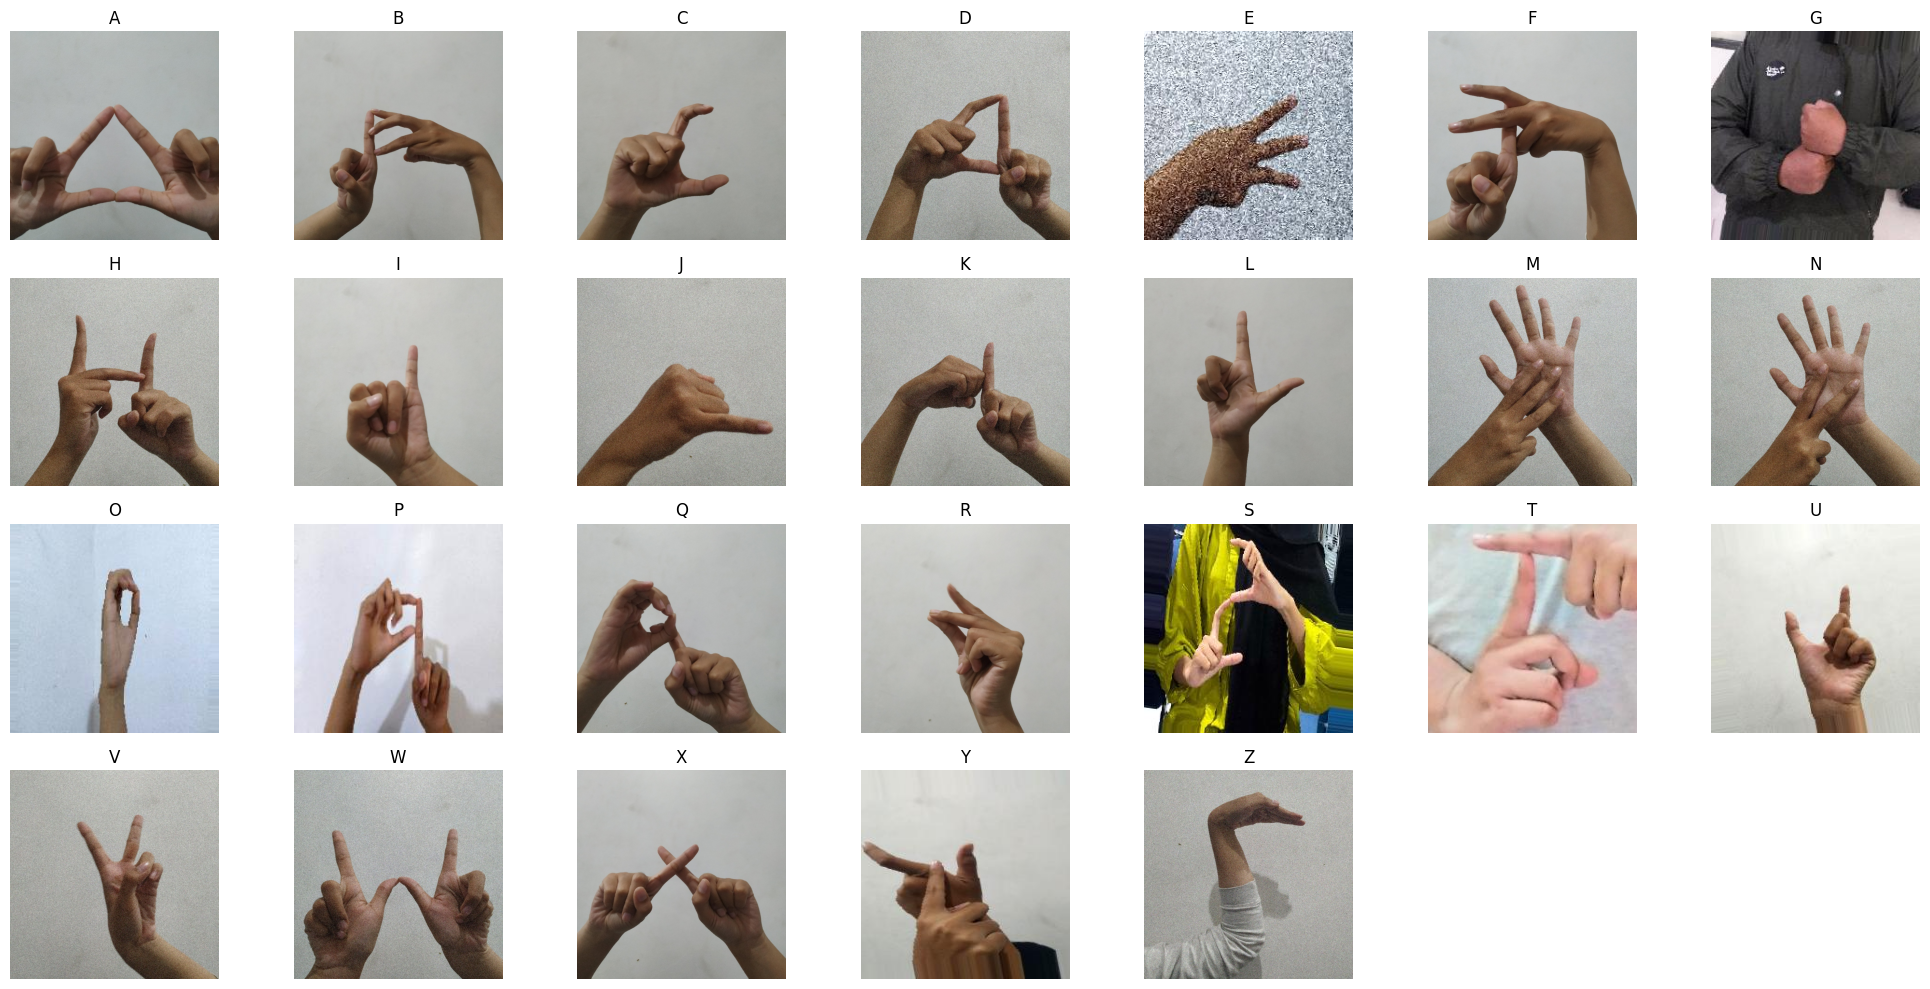

In [6]:
import matplotlib.image as mpimg

# Ambil list semua folder (kelas)
class_folders = sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))])

# Buat plot
plt.figure(figsize=(20, 10))

# Loop setiap kelas dan ambil satu gambar
for i, class_name in enumerate(class_folders):
    class_path = os.path.join(test_dir, class_name)
    images = os.listdir(class_path)
    if images:  # Pastikan folder tidak kosong
        img_path = os.path.join(class_path, images[0])  # Ambil gambar pertama
        img = mpimg.imread(img_path)

        # Plot
        plt.subplot(4, 7, i + 1)  # 4 baris, 7 kolom (cocok untuk 26 kelas)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')

plt.tight_layout()
plt.show()


### Prapemrosesan Dataset dengan Image Data Generator

In [7]:
# ImageDataGenerator untuk augmentasi data
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    rescale=1./255,
    brightness_range=[0.5, 1.5],
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# Create training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Create validation generator
val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Create testing generator
test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 9169 images belonging to 26 classes.
Found 1924 images belonging to 26 classes.
Found 1924 images belonging to 26 classes.


In [10]:
# Perancangan arsitektur CNN dengan base model MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_SIZE,IMG_SIZE,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable=False

# Custom model MobileNetV2
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling
x = Flatten()(x)
x = Dense(256, activation='relu')(x)  # Fully connected layer
x = Dropout(0.3)(x)  # Dropout layer to prevent overfitting
outputs = Dense(26, activation='softmax')(x)  # Output layer for 26

# Build the final model
model = Model(inputs=base_model.input, outputs=outputs)
print("Panjang Layer Model:",len(model.layers))

Panjang Layer Model: 159


In [ ]:
import tensorflow as tf

class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

# Compile Model 
optimizer = Adam(learning_rate=0.0010)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        F1Score(name='f1score')
    ]
)



In [13]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
)

C:\Users\ACER\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 205s 804ms/step - accuracy: 0.5776 - f1score: 0.5209 - loss: 1.6603 - precision: 0.9208 - recall: 0.3913 - val_accuracy: 0.6760 - val_f1score: 0.7211 - val_loss: 1.0558 - val_precision: 0.9549 - val_recall: 0.5793
Epoch 2/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 120s 475ms/step - accuracy: 0.8593 - f1score: 0.8793 - loss: 0.5034 - precision: 0.9642 - recall: 0.8082 - val_accuracy: 0.7331 - val_f1score: 0.7451 - val_loss: 0.8729 - val_precision: 0.9373 - val_recall: 0.6183
Epoch 3/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 120s 477ms/step - accuracy: 0.8860 - f1score: 0.9013 - loss: 0.3962 - precision: 0.9696 - recall: 0.8421 - val_accuracy: 0.7558 - val_f1score: 0.7682 - val_loss: 0.7494 - val_precision: 0.9196 - val_recall: 0.6597
Epoch 4/100
252/252 ━━━━━━━━━━━━━━━━━━━━ 122s 484ms/step - accuracy: 0.8863 - f1score: 0.9027 - loss: 0.3712 - precision: 0.9648 - recall: 0.8481 - val_accuracy: 0.7791 - val_f1score: 0.8011 - val_loss: 0.6733 - val_precision: 0.9212 -

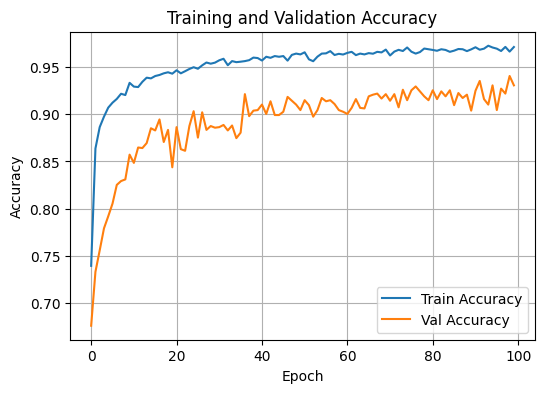

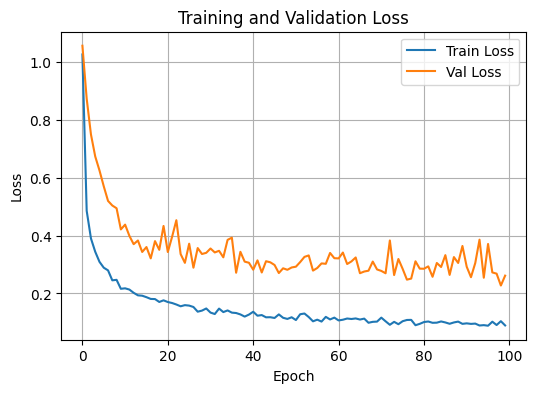

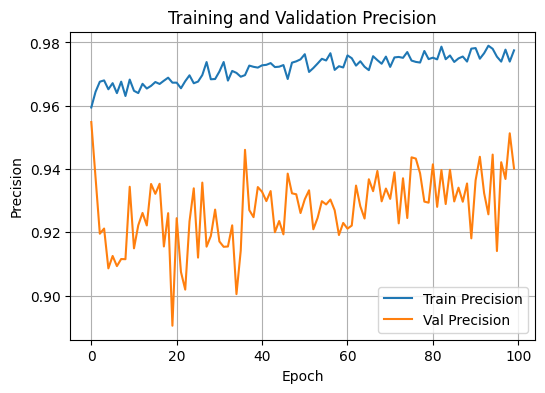

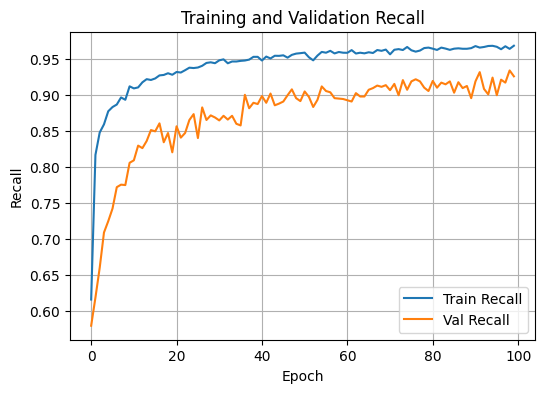

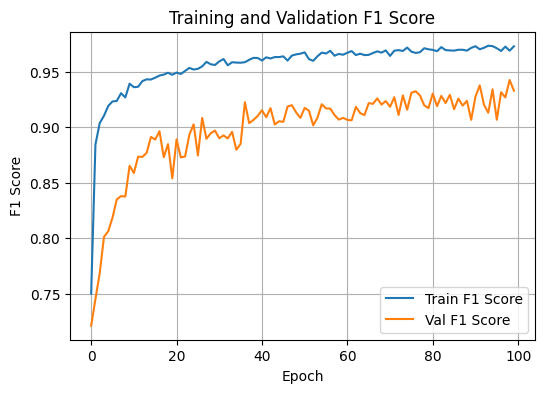

In [16]:
import matplotlib.pyplot as plt

# Asumsikan Anda sudah punya history dari model.fit()
# history = model.fit(...)

# Grafik 1: Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 2: Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 3: Precision
plt.figure(figsize=(6, 4))
plt.plot(history.history['precision'], label='Train Precision')
plt.plot(history.history['val_precision'], label='Val Precision')
plt.title('Training and Validation Precision')
plt.xlabel('Epoch')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 4: Recall
plt.figure(figsize=(6, 4))
plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Val Recall')
plt.title('Training and Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.legend()
plt.grid(True)
plt.show()

# Grafik 5: F1 Score
plt.figure(figsize=(6, 4))
plt.plot(history.history['f1score'], label='Train F1 Score')
plt.plot(history.history['val_f1score'], label='Val F1 Score')
plt.title('Training and Validation F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
# Menyimpan model setelah pelatihan selesai
model.save('mobilenetv2.keras')

In [13]:
# Evaluasi model
loss, accuracy, precision, recall, f1_score = model.evaluate(val_generator)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1_score}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - accuracy: 0.9761 - f1score: 0.9751 - loss: 0.0913 - precision: 0.9766 - recall: 0.9736
Loss: 0.13261312246322632
Accuracy: 0.969854474067688
Precision: 0.972294807434082
Recall: 0.9667359590530396
F1-Score: 0.9695073962211609


In [10]:
from tensorflow.keras.metrics import Metric
from tensorflow.keras import backend as K
from keras.saving import register_keras_serializable

@register_keras_serializable()
class F1Score(Metric):
    def __init__(self, name='f1score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + K.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()


model = tf.keras.models.load_model(
    r"C:\Users\ACER\Downloads\dump\task\mobilenetv2.keras",
    custom_objects={'F1Score': F1Score}
)


In [11]:
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ambil ground truth label
y_true = val_generator.classes

# Ambil prediksi dari model
y_pred_prob = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Hitung metric global manual
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(val_generator.class_indices.keys())))


C:\Users\ACER\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


61/61 ━━━━━━━━━━━━━━━━━━━━ 26s 419ms/step
Accuracy:  0.9699
Precision: 0.9710
Recall:    0.9699
F1 Score:  0.9699

Classification Report:

              precision    recall  f1-score   support

           A       0.90      0.97      0.94        74
           B       0.96      1.00      0.98        74
           C       0.95      1.00      0.97        74
           D       0.99      0.97      0.98        74
           E       0.99      0.92      0.95        74
           F       1.00      0.95      0.97        74
           G       0.99      1.00      0.99        74
           H       0.99      0.96      0.97        74
           I       0.92      0.99      0.95        74
           J       0.97      0.99      0.98        74
           K       0.96      1.00      0.98        74
           L       0.92      0.99      0.95        74
           M       0.96      0.96      0.96        74
           N       0.96      0.95      0.95        74
           O       1.00      1.00      1.00       

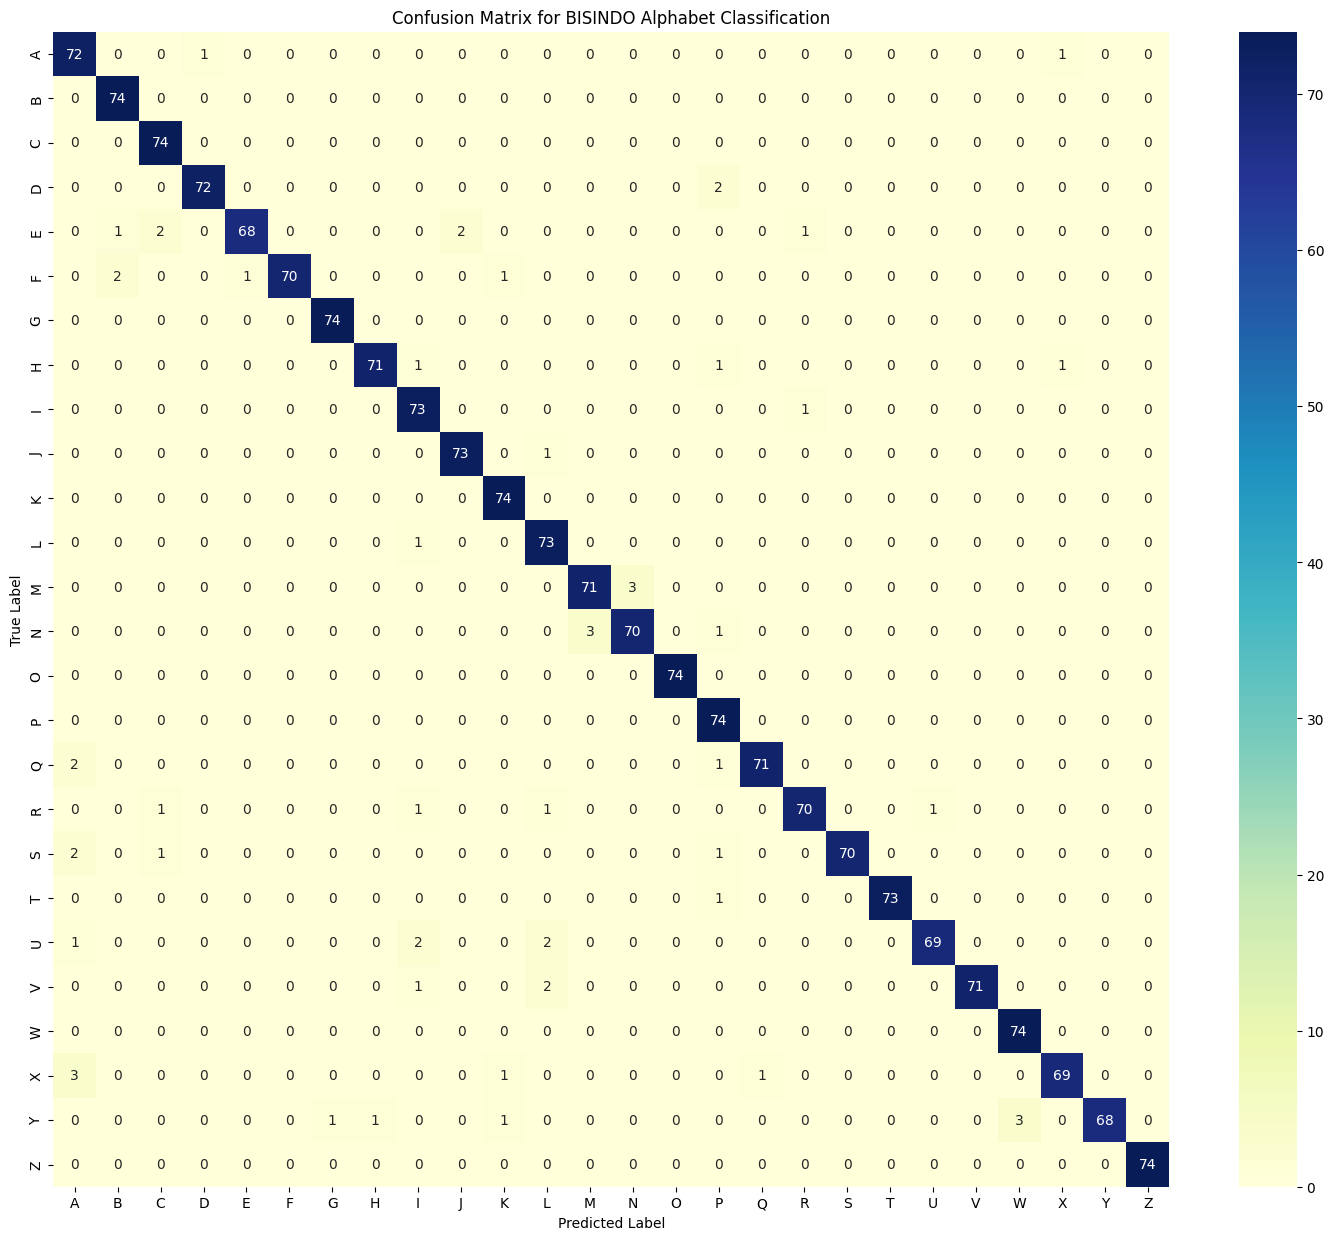

In [14]:
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.metrics import confusion_matrix  
import string  


# Label nama kelas A-Z
labels = list(string.ascii_uppercase)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for BISINDO Alphabet Classification')
plt.show()


In [15]:
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Ambil ground truth label
y_true = test_generator.classes

# Ambil prediksi dari model
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Hitung metric global manual
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(test_generator.class_indices.keys())))


C:\Users\ACER\AppData\Roaming\Python\Python39\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 264ms/step
Accuracy:  0.8675
Precision: 0.8786
Recall:    0.8675
F1 Score:  0.8651

Classification Report:

              precision    recall  f1-score   support

           A       0.80      0.97      0.88        74
           B       0.89      0.97      0.93        74
           C       0.83      0.95      0.89        74
           D       0.80      0.89      0.84        74
           E       0.97      0.76      0.85        74
           F       0.90      0.85      0.88        74
           G       0.89      0.88      0.88        74
           H       0.92      0.81      0.86        74
           I       0.69      0.97      0.80        74
           J       0.83      0.95      0.89        74
           K       0.86      0.93      0.90        74
           L       0.88      0.96      0.92        74
           M       0.77      0.91      0.83        74
           N       0.90      0.77      0.83        74
           O       1.00      0.97      0.99       

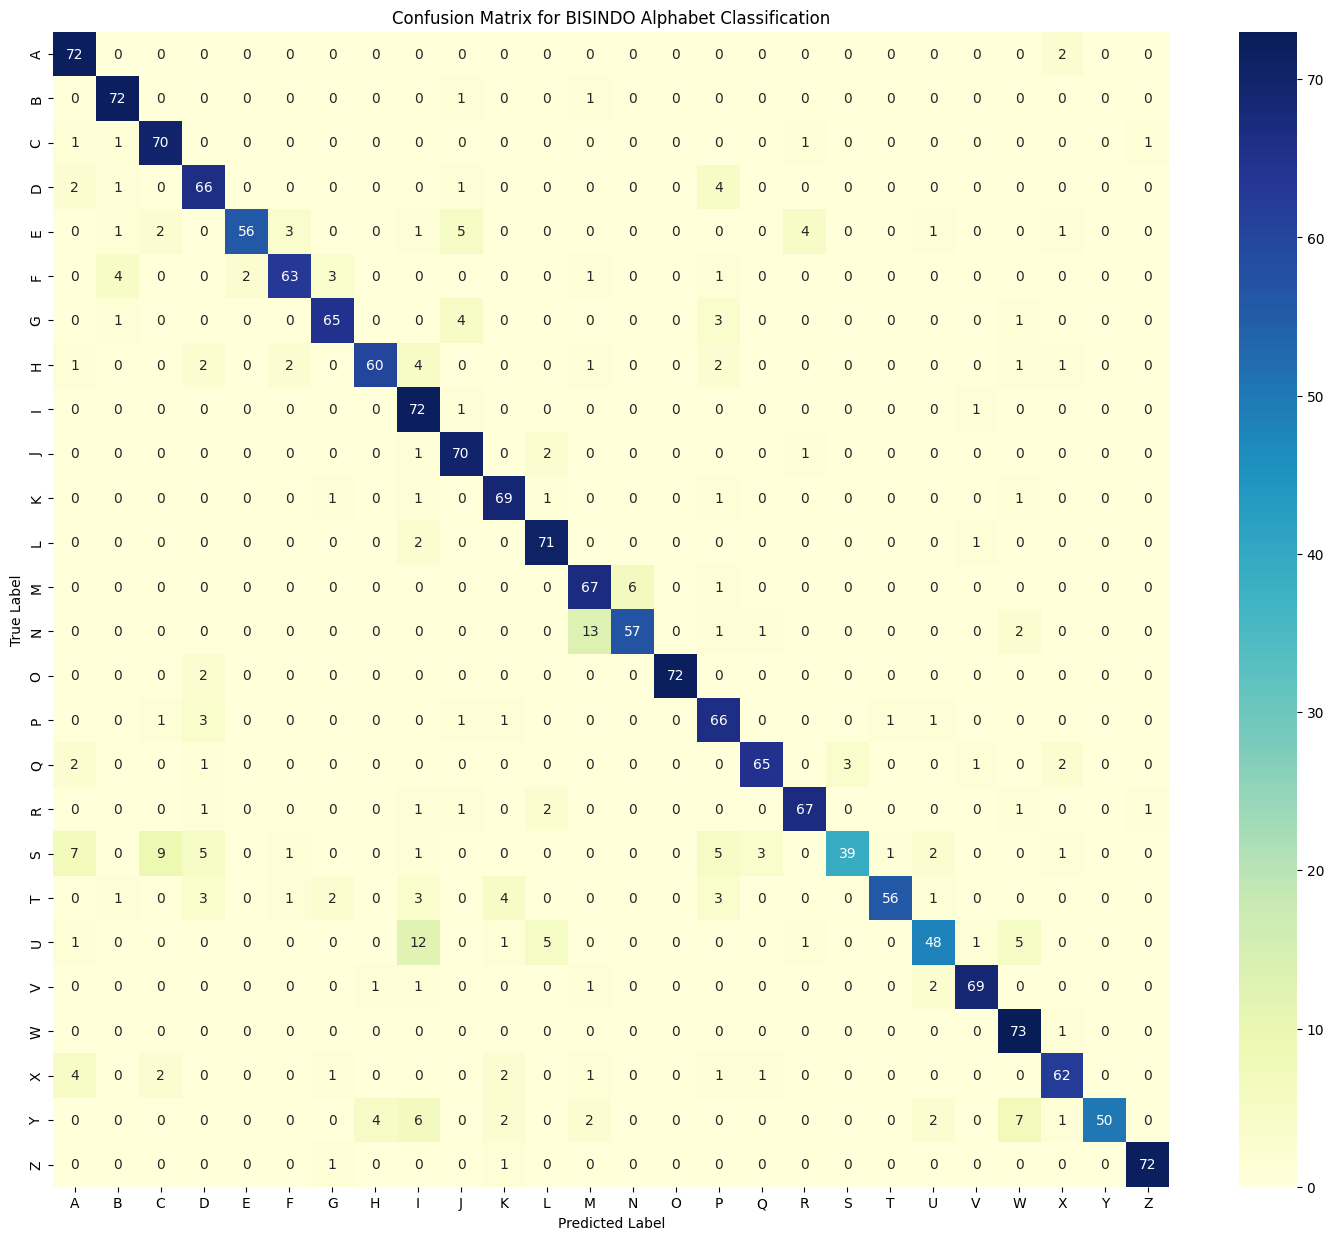

In [16]:
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.metrics import confusion_matrix  
import string  


# Label nama kelas A-Z
labels = list(string.ascii_uppercase)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for BISINDO Alphabet Classification')
plt.show()


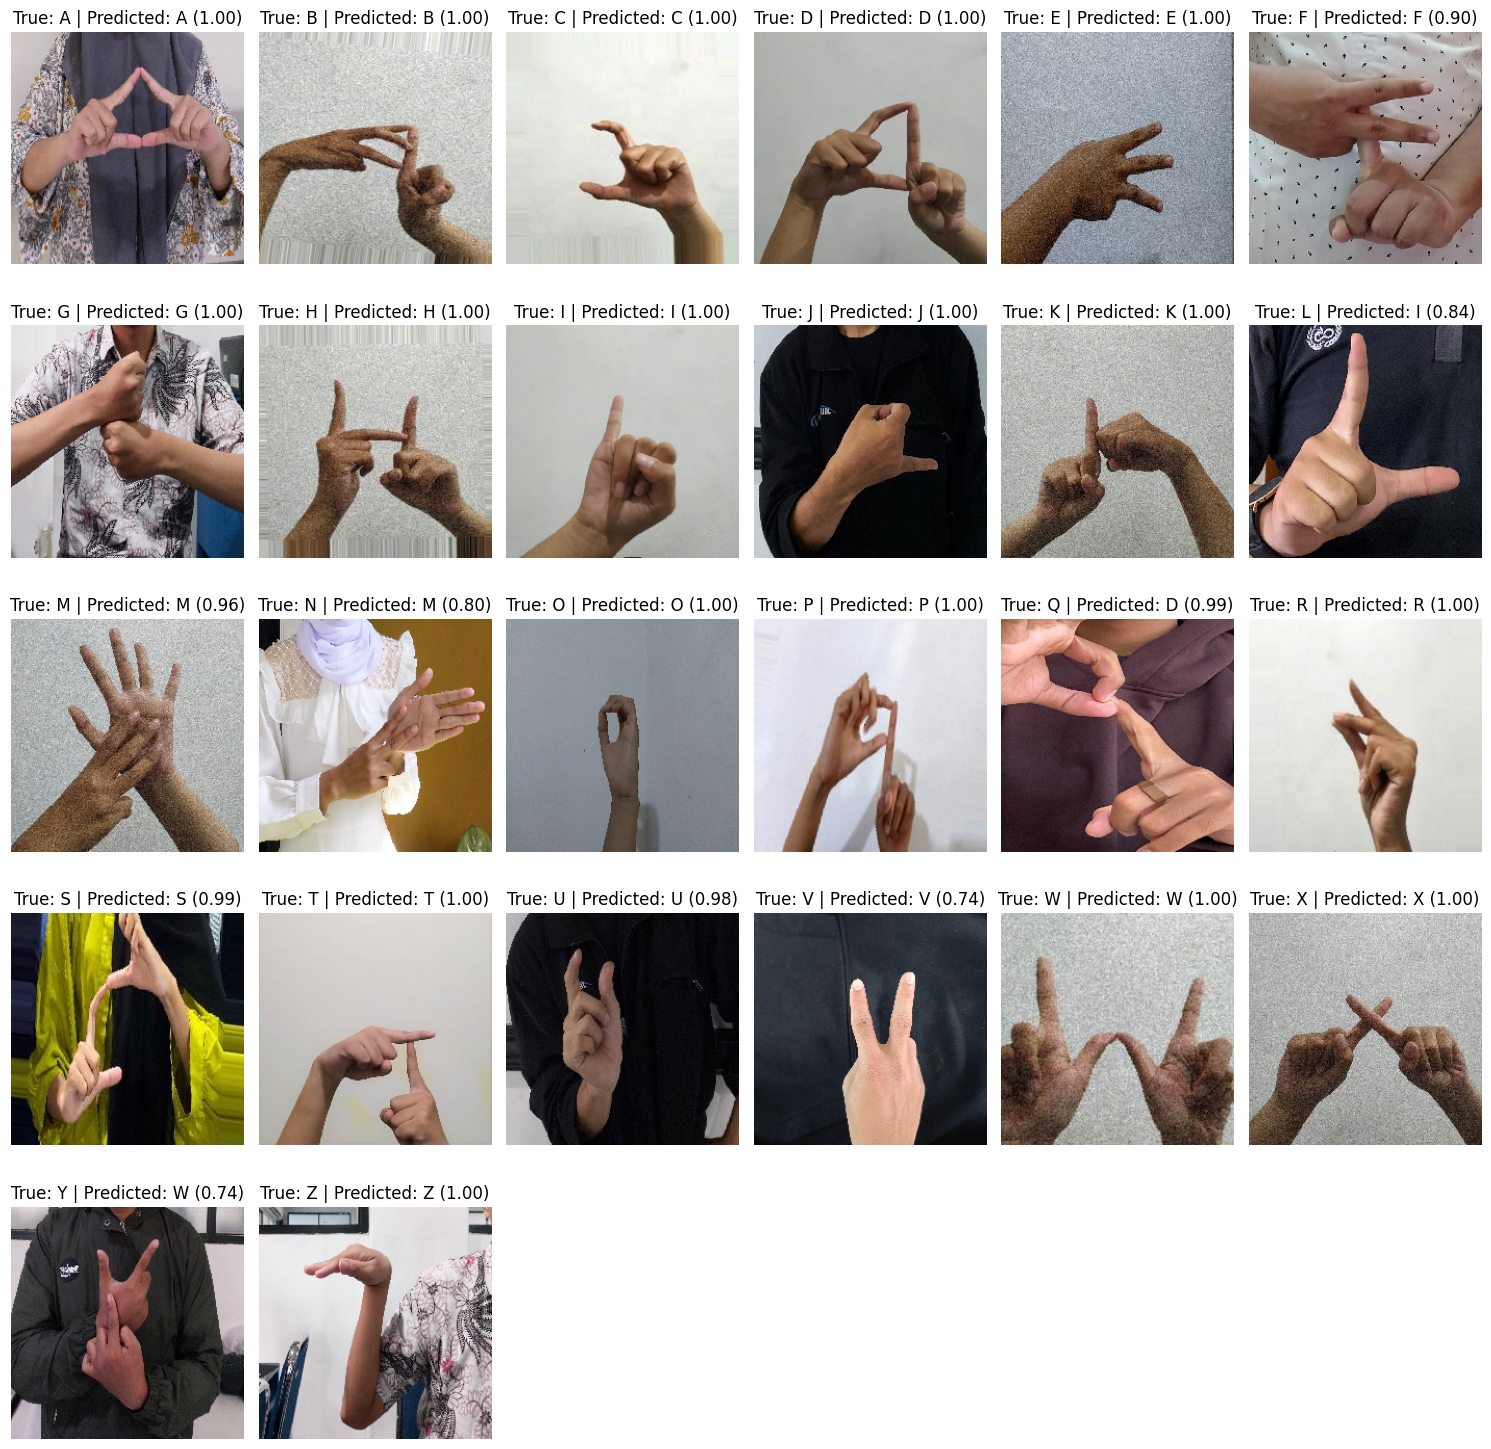

In [20]:
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Metric
import tensorflow as tf
from keras.saving import register_keras_serializable

# === Definisi F1Score Custom ===
@register_keras_serializable()
class F1Score(Metric):
    def __init__(self, name='f1score', **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.precision = tf.keras.metrics.Precision()
        self.recall = tf.keras.metrics.Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

# === Konfigurasi ===
model_path = r'C:\Users\ACER\Downloads\dump\task\mobilenetv2.keras'
image_folder = r'C:\Users\ACER\Downloads\dump\task\data\test'
img_size = (224, 224)

# === Load model dengan custom_objects ===
model = load_model(model_path, custom_objects={'F1Score': F1Score})
class_names = sorted(os.listdir(image_folder))

# === Fungsi prediksi dan visualisasi ===
def predict_and_plot(folder_path, true_label):
    images = [img for img in os.listdir(folder_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not images:
        return False
    img_file = random.choice(images)
    img_path = os.path.join(folder_path, img_file)

    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]
    confidence = np.max(prediction)

    plt.imshow(img)
    plt.title(f"True: {true_label} | Predicted: {predicted_label} ({confidence:.2f})")
    plt.axis('off')
    return True

# === Visualisasi hasil prediksi satu gambar per folder ===
plt.figure(figsize=(15, 15))
rows = 5
cols = 6

i = 1
for label_folder in class_names:
    folder_path = os.path.join(image_folder, label_folder)
    if os.path.isdir(folder_path):
        plt.subplot(rows, cols, i)
        success = predict_and_plot(folder_path, label_folder)
        if success:
            i += 1
        if i > rows * cols:
            break

plt.tight_layout()
plt.show()
